# Сбор данных: MOEX ISS + Тинькофф Invest API

**Цель:** построить локальную базу исторических и real-time данных по фьючерсам Si, BR, RI для исследования стратегий.


In [21]:
import requests
import pandas as pd
import numpy as np
import sqlite3
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

DB_PATH = Path("data/market_data.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

In [22]:
MOEX_BASE = "https://iss.moex.com/iss"

# Интервалы: 1 (1мин), 10 (10мин), 60 (1ч), 24 (1д)
# engine=futures, market=forts для фьючерсов

def moex_get_candles(
    security: str,
    interval: int = 60,
    start: str = "2024-01-01",
    end: str | None = None,
    engine: str = "futures",
    market: str = "forts",
) -> pd.DataFrame:
    """Скачать свечи с MOEX ISS постранично."""
    
    if end is None:
        end = datetime.now().strftime("%Y-%m-%d")
    
    all_rows = []
    page_start = 0
    
    while True:
        url = (
            f"{MOEX_BASE}/engines/{engine}/markets/{market}"
            f"/securities/{security}/candles.json"
        )
        params = {
            "from": start,
            "till": end,
            "interval": interval,
            "start": page_start,
        }
        
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        
        candles = data["candles"]
        columns = candles["columns"]
        rows = candles["data"]
        
        if not rows:
            break
        
        all_rows.extend(rows)
        page_start += len(rows)
        time.sleep(0.25)  # rate limit
    
    if not all_rows:
        print(f"Нет данных для {security}")
        return pd.DataFrame()
    
    df = pd.DataFrame(all_rows, columns=columns)
    df["begin"] = pd.to_datetime(df["begin"])
    df["end"] = pd.to_datetime(df["end"])
    df = df.rename(columns={
        "begin": "timestamp",
        "open": "open",
        "close": "close",
        "high": "high",
        "low": "low",
        "value": "volume_rub",
        "volume": "volume_contracts",
    })
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

In [13]:
def moex_find_futures(base_asset: str = "Si") -> pd.DataFrame:
    """Найти все фьючерсы по базовому активу (Si, BR, RI и т.д.)."""
    url = f"{MOEX_BASE}/engines/futures/markets/forts/securities.json"
    params = {"iss.meta": "off", "iss.only": "securities"}
    
    resp = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    
    cols = data["securities"]["columns"]
    rows = data["securities"]["data"]
    df = pd.DataFrame(rows, columns=cols)
    
    mask = df["SECID"].str.startswith(base_asset)
    result = df[mask][["SECID", "SHORTNAME", "LASTTRADEDATE", "PREVOPENPOSITION", "INITIALMARGIN"]].copy()
    result = result.sort_values("LASTTRADEDATE")
    return result

for asset in ["Si", "BR", "RI"]:
    print(f"\n{'='*40}")
    print(f"  {asset} — активные фьючерсы")
    print(f"{'='*40}")
    futures = moex_find_futures(asset)
    if not futures.empty:
        display(futures)
    else:
        print("Не найдено")


  Si — активные фьючерсы


,SECID,SHORTNAME,LASTTRADEDATE,PREVOPENPOSITION,INITIALMARGIN
357,SiM6,Si-6.26,2026-06-18,9267156,11049.19
359,SiU6,Si-9.26,2026-09-17,3112946,11497.12
361,SiZ6,Si-12.26,2026-12-17,98938,11953.39
356,SiH7,Si-3.27,2027-03-18,3528,12545.48
358,SiM7,Si-6.27,2027-06-17,1918,13179.91
360,SiU7,Si-9.27,2027-09-16,334,13837.82



  BR — активные фьючерсы


,SECID,SHORTNAME,LASTTRADEDATE,PREVOPENPOSITION,INITIALMARGIN
43,BRM6,BR-6.26,2026-06-01,566526,15019.52
44,BRN6,BR-7.26,2026-07-01,208766,16712.60
45,BRQ6,BR-8.26,2026-08-03,21382,16491.89
46,BRU6,BR-9.26,2026-08-31,9568,16581.59
47,BRV6,BR-10.26,2026-10-01,4384,17004.09
48,BRX6,BR-11.26,2026-11-02,2526,17353.36
49,BRZ6,BR-12.26,2026-12-01,1456,17606.62
42,BRF7,BR-1.27,2027-01-04,102,17654.80



  RI — активные фьючерсы


,SECID,SHORTNAME,LASTTRADEDATE,PREVOPENPOSITION,INITIALMARGIN
307,RIM6,RTS-6.26,2026-06-18,46332,25249.02
309,RIU6,RTS-9.26,2026-09-17,4218,26361.97
310,RIZ6,RTS-12.26,2026-12-17,268,27431.17
306,RIH7,RTS-3.27,2027-03-18,120,28764.35
308,RIM7,RTS-6.27,2027-06-17,28,30214.42


In [14]:
TICKERS = {
    "Si": "SiM6",   # доллар/рубль — 9.2M OI
    "BR": "BRM6",   # нефть Brent  — 566K OI
    "RI": "RIM6",   # индекс РТС   — 46K OI
}

candles = {}
for name, ticker in TICKERS.items():
    print(f"Скачиваю {name} ({ticker})...")
    df = moex_get_candles(ticker, interval=60, start="2025-01-01")
    candles[name] = df
    if len(df) > 0:
        print(f"  → {len(df)} свечей, с {df['timestamp'].min().date()} по {df['timestamp'].max().date()}")
    else:
        print("  → нет данных")

Скачиваю Si (SiM6)...
  → 3454 свечей, с 2025-01-03 по 2026-05-27
Скачиваю BR (BRM6)...
  → 2174 свечей, с 2025-10-30 по 2026-05-27
Скачиваю RI (RIM6)...
  → 2319 свечей, с 2025-01-16 по 2026-05-27

Готово!


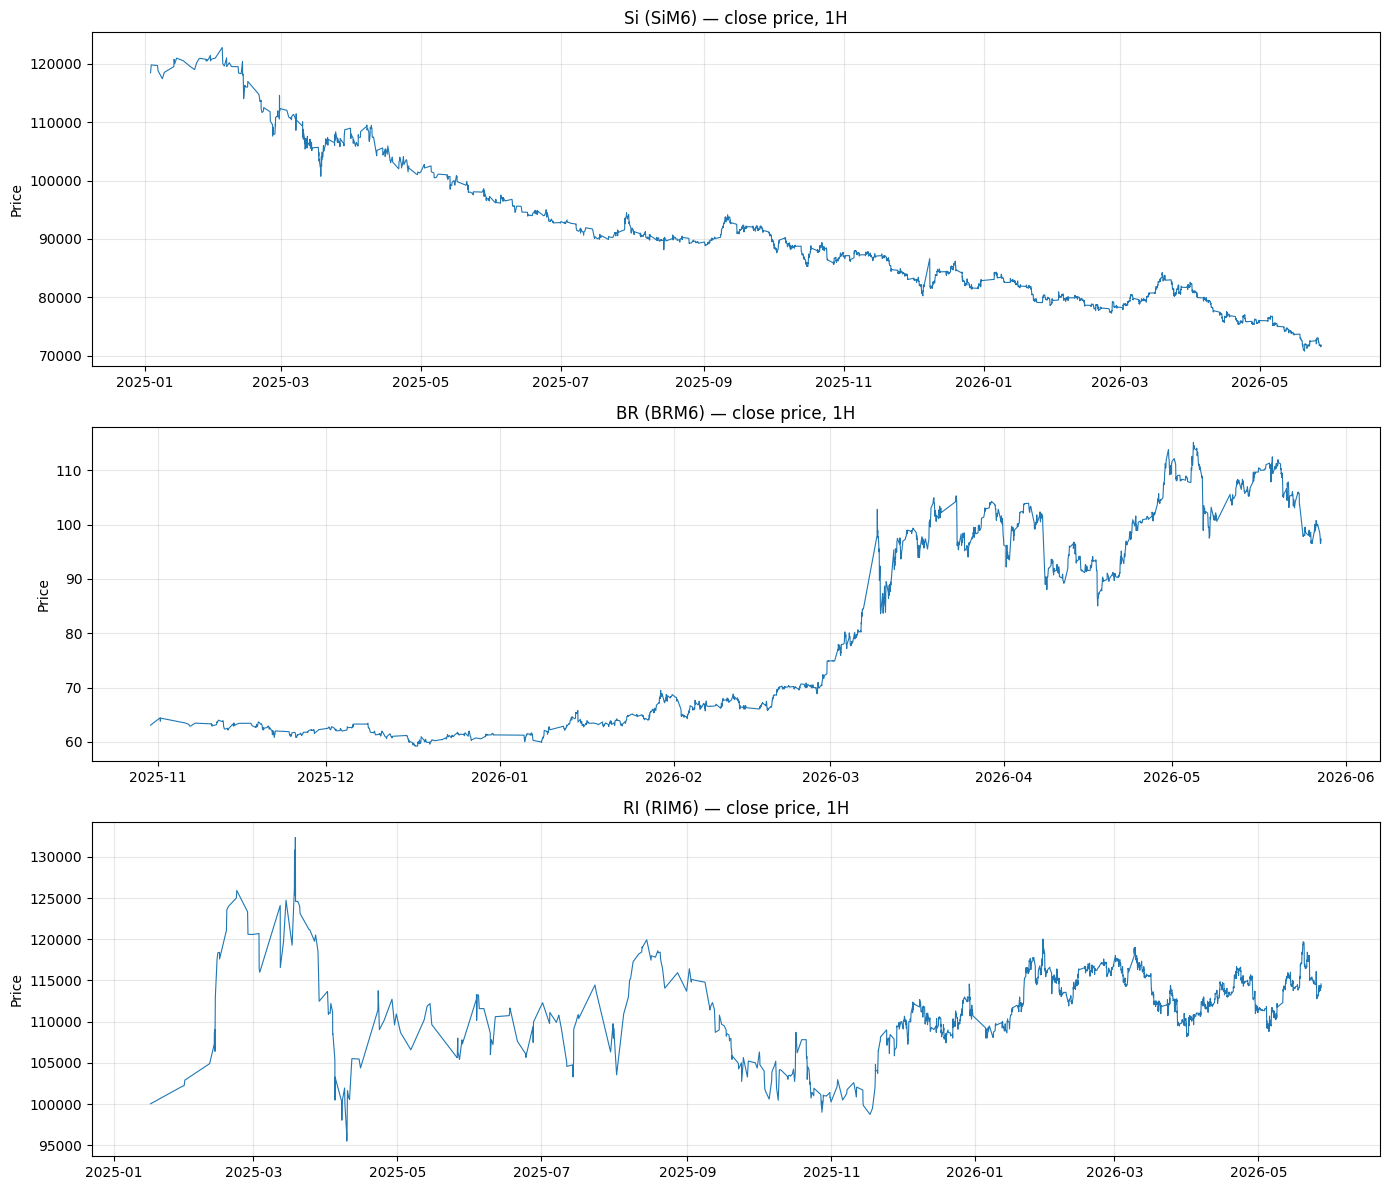

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(candles), 1, figsize=(14, 4 * len(candles)), sharex=False)
if len(candles) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, candles.items()):
    if df.empty:
        ax.set_title(f"{name} — нет данных")
        continue
    ax.plot(df["timestamp"], df["close"], linewidth=0.8)
    ax.set_title(f"{name} ({TICKERS[name]}) — close price, 1H")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Сохраняем в SQLite

In [16]:
def save_candles_to_db(df: pd.DataFrame, instrument: str, timeframe: str = "1H"):
    """Сохранить свечи в SQLite с дедупликацией."""
    conn = sqlite3.connect(DB_PATH)
    
    conn.execute("""
        CREATE TABLE IF NOT EXISTS candles (
            instrument TEXT,
            timeframe TEXT,
            timestamp TEXT,
            open REAL,
            high REAL,
            low REAL,
            close REAL,
            volume_contracts INTEGER,
            volume_rub REAL,
            PRIMARY KEY (instrument, timeframe, timestamp)
        )
    """)
    
    records = df[["timestamp", "open", "high", "low", "close", "volume_contracts", "volume_rub"]].copy()
    records["instrument"] = instrument
    records["timeframe"] = timeframe
    records["timestamp"] = records["timestamp"].astype(str)
    
    records.to_sql("candles", conn, if_exists="append", index=False, method="multi")
    conn.commit()
    
    count = conn.execute(
        "SELECT COUNT(*) FROM candles WHERE instrument=? AND timeframe=?",
        (instrument, timeframe)
    ).fetchone()[0]
    
    conn.close()
    print(f"  {instrument} ({timeframe}): {count} записей в БД")

for name, df in candles.items():
    if not df.empty:
        save_candles_to_db(df, name, "1H")

print(f"\nБД: {DB_PATH} ({DB_PATH.stat().st_size / 1024:.0f} KB)")

  Si (1H): 3454 записей в БД
  BR (1H): 2174 записей в БД
  RI (1H): 2319 записей в БД

БД: data/market_data.db (760 KB)


## 2. Тинькофф Invest API

In [23]:
import os
from dotenv import load_dotenv
from tinkoff.invest import Client

load_dotenv()

TINKOFF_TOKEN = os.getenv("TINKOFF_TOKEN")
if not TINKOFF_TOKEN:
    print(" Токен не найден.")
else:
    print(f"✓ Токен загружен ({TINKOFF_TOKEN[:6]}...{TINKOFF_TOKEN[-4:]})")

# Проверка подключения
with Client(TINKOFF_TOKEN) as client:
    accounts = client.users.get_accounts()
    for acc in accounts.accounts:
        print(f"  Счёт: {acc.name} ({acc.id}) — {acc.type.name}")

✓ Токен загружен (t.tK8o...4ySQ)
  Счёт: Брокерский счёт (2043432828) — ACCOUNT_TYPE_TINKOFF
  Счёт: ИИС (2062498056) — ACCOUNT_TYPE_TINKOFF_IIS


In [18]:
from tinkoff.invest import InstrumentStatus

def tinkoff_find_futures(base_asset: str = "Si") -> pd.DataFrame:
    """Найти фьючерсы через Тинькофф SDK."""
    with Client(TINKOFF_TOKEN) as client:
        resp = client.instruments.futures(
            instrument_status=InstrumentStatus.INSTRUMENT_STATUS_BASE
        )
    
    results = []
    for f in resp.instruments:
        if f.ticker.startswith(base_asset):
            results.append({
                "ticker": f.ticker,
                "uid": f.uid,
                "figi": f.figi,
                "name": f.name,
                "lot": f.lot,
                "expiration": f.expiration_date,
            })
    
    return pd.DataFrame(results).sort_values("expiration") if results else pd.DataFrame()

for asset in ["Si", "BR", "RI"]:
    print(f"\n--- {asset} ---")
    df_f = tinkoff_find_futures(asset)
    display(df_f) if not df_f.empty else print("Не найдено")


--- Si ---


,ticker,uid,figi,name,lot,expiration
4,SiM6,b4df2961-035a-4dcd-8372-9af0db10d2c9,FUTSI0626000,Si-6.26 Курс Доллар – Рубль,1,2026-06-19 00:00:00+00:00
1,SiU6,574d37d8-9de4-423a-9e33-b936002d8bda,FUTSI0926000,Si-9.26 Курс Доллар – Рубль,1,2026-09-18 00:00:00+00:00
3,SiZ6,2dd5eb6b-7a52-4186-a0ec-9f7f6ed6fbd7,FUTSI1226000,Si-12.26 Курс Доллар – Рубль,1,2026-12-18 00:00:00+00:00
5,SiH7,76d6a73e-c555-4de6-a66d-be99d96ed449,FUTSi0327000,Si-3.27 Курс Доллар – Рубль,1,2027-03-19 00:00:00+00:00
0,SiM7,fa523cf8-27cb-4582-8f8c-74ddee9e6703,FUTSi0627000,Si-6.27 Курс Доллар – Рубль,1,2027-06-18 00:00:00+00:00
2,SiU7,85a2eee9-1792-47df-a99b-3719ef01cbe7,FSi092700000,Si-9.27 Курс Доллар – Рубль,1,2027-09-17 00:00:00+00:00



--- BR ---


,ticker,uid,figi,name,lot,expiration
0,BRM6,133d73d0-d86c-4976-8333-0437f1e26f16,FUTBR0626000,BR-6.26 Нефть Brent,1,2026-06-02 00:00:00+00:00
4,BRN6,2ae01b47-c07a-4378-92d2-192eac373447,FUTBR0726000,BR-7.26 Нефть Brent,1,2026-07-02 00:00:00+00:00
7,BRQ6,9121d88e-71b0-41ac-b89d-96d90aa8b7f6,FUTBR0826000,BR-8.26 Нефть Brent,1,2026-08-04 00:00:00+00:00
5,BRU6,afba584a-b4bd-459e-a1a4-038b4b18e38f,FUTBR0826100,BR-9.26 Нефть Brent,1,2026-09-01 00:00:00+00:00
6,BRV6,c8968ffd-db1c-4a35-9f6f-7013a2b7c35a,FBR102600000,BR-10.26 Нефть Brent,1,2026-10-02 00:00:00+00:00
3,BRX6,b2d0f863-f834-460b-ae66-420a4dace272,FBR112600000,BR-11.26 Нефть Brent,1,2026-11-03 00:00:00+00:00
1,BRZ6,5f72f0f4-c326-46e6-a2d3-1632c74c76df,FBR122600000,BR-12.26 Нефть Brent,1,2026-12-02 00:00:00+00:00
2,BRF7,dba04c3e-5ce2-406c-9ba9-64e226492611,FBR012700000,BR-1.27 Нефть Brent,1,2027-01-05 00:00:00+00:00



--- RI ---


,ticker,uid,figi,name,lot,expiration
2,RIM6,75ae795b-e89f-4ce8-8b67-e1cc76b07a42,FUTRTS062600,RTS-6.26 Индекс РТС,1,2026-06-19 00:00:00+00:00
0,RIU6,4c7312c3-6f66-46a1-a65b-ed399b90276e,FUTRTS092600,RTS-9.26 Индекс РТС,1,2026-09-18 00:00:00+00:00
1,RIZ6,8644937a-4b06-4710-8b9f-7085d893f95d,FUTRTS122600,RTS-12.26 Индекс РТС,1,2026-12-18 00:00:00+00:00
4,RIH7,3ae23307-715c-4daf-aac1-8f20578899df,FUTRTS032700,RTS-3.27 Индекс РТС,1,2027-03-19 00:00:00+00:00
3,RIM7,1d4db2a5-46a7-404a-983f-dcbda14caf00,FUTRTS062700,RTS-6.27 Индекс РТС,1,2027-06-18 00:00:00+00:00


### Свечи через Тинькофф REST API

In [24]:
from tinkoff.invest import CandleInterval
from tinkoff.invest.utils import now as ti_now

INTERVAL_MAP = {
    "1min":  CandleInterval.CANDLE_INTERVAL_1_MIN,
    "5min":  CandleInterval.CANDLE_INTERVAL_5_MIN,
    "15min": CandleInterval.CANDLE_INTERVAL_15_MIN,
    "1h":    CandleInterval.CANDLE_INTERVAL_HOUR,
    "1d":    CandleInterval.CANDLE_INTERVAL_DAY,
}

# UID ближайших контрактов (из таблицы выше)
TICKERS_UID = {
    "Si": "b4df2961-035a-4dcd-8372-9af0db10d2c9",  # SiM6
    "BR": "133d73d0-d86c-4976-8333-0437f1e26f16",  # BRM6
    "RI": "75ae795b-e89f-4ce8-8b67-e1cc76b07a42",  # RIM6
}

def tinkoff_get_candles(uid: str, interval: str = "1h",
                        start: str = "2025-01-01") -> pd.DataFrame:
    """Скачать все свечи через SDK (get_all_candles — автоматическая пагинация)."""
    from_dt = datetime.fromisoformat(start).replace(tzinfo=timezone.utc)
    
    rows = []
    with Client(TINKOFF_TOKEN) as client:
        for candle in client.get_all_candles(
            instrument_id=uid,
            from_=from_dt,
            to=ti_now(),
            interval=INTERVAL_MAP[interval],
        ):
            def q(x): return x.units + x.nano / 1e9
            rows.append({
                "timestamp": candle.time,
                "open":  q(candle.open),
                "high":  q(candle.high),
                "low":   q(candle.low),
                "close": q(candle.close),
                "volume_contracts": candle.volume,
                "is_complete": candle.is_complete,
            })
    
    if not rows:
        return pd.DataFrame()
    
    df = pd.DataFrame(rows)
    df = df[df["is_complete"]].drop(columns="is_complete")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

# Скачиваем часовые свечи по всем трём через Тинькофф
candles_tk = {}
for name, uid in TICKERS_UID.items():
    print(f"Скачиваю {name} через Тинькофф...")
    df = tinkoff_get_candles(uid, interval="1h", start="2025-01-01")
    candles_tk[name] = df
    if not df.empty:
        print(f"  → {len(df)} свечей, с {df['timestamp'].min().date()} по {df['timestamp'].max().date()}")
    else:
        print("  → нет данных")

Скачиваю Si через Тинькофф...
  → 3428 свечей, с 2025-01-03 по 2026-05-27
Скачиваю BR через Тинькофф...
  → 2157 свечей, с 2025-10-30 по 2026-05-27
Скачиваю RI через Тинькофф...
  → 2299 свечей, с 2025-01-16 по 2026-05-27


## 3. Первичный анализ: Lead-Lag BR → Si

Проверяем гипотезу: нефть (BR) двигается раньше рубля (Si). Если лаг существует — это tradeable signal.

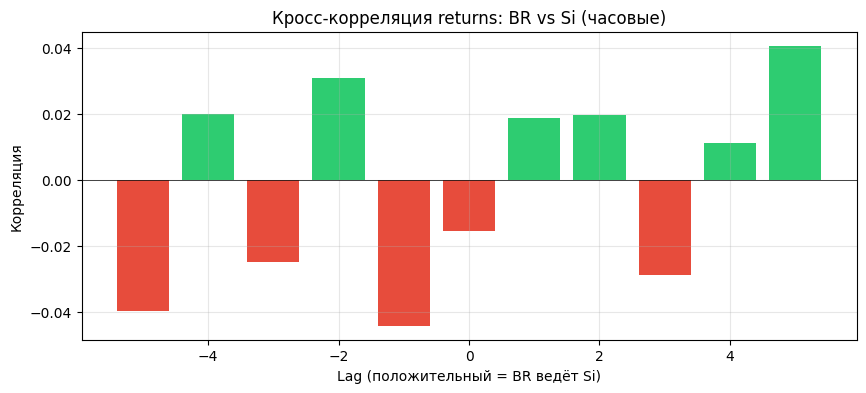

Максимальная корреляция при лаге = -1 (-0.0442)


In [25]:
def compute_lead_lag(df_leader: pd.DataFrame, df_follower: pd.DataFrame, max_lag: int = 10):
    """Кросс-корреляция returns лидера и фолловера с разными лагами."""
    
    leader = df_leader.set_index("timestamp")["close"].resample("1h").last().dropna()
    follower = df_follower.set_index("timestamp")["close"].resample("1h").last().dropna()
    
    idx = leader.index.intersection(follower.index)
    leader = leader.loc[idx].pct_change().dropna()
    follower = follower.loc[idx].pct_change().dropna()
    
    idx2 = leader.index.intersection(follower.index)
    leader = leader.loc[idx2]
    follower = follower.loc[idx2]
    
    results = []
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            corr = leader.iloc[:-lag].corr(follower.iloc[lag:].values if hasattr(follower.iloc[lag:], 'values') else follower.shift(-lag).dropna())
            corr = leader.corr(follower.shift(-lag).dropna().reindex(leader.index).dropna())
        elif lag < 0:
            corr = leader.corr(follower.shift(-lag).dropna().reindex(leader.index).dropna())
        else:
            corr = leader.corr(follower)
        
        results.append({"lag": lag, "correlation": corr})
    
    return pd.DataFrame(results)

# Простая версия — корреляция через shift
if "BR" in candles and "Si" in candles and not candles["BR"].empty and not candles["Si"].empty:
    br = candles["BR"].set_index("timestamp")["close"].pct_change().dropna()
    si = candles["Si"].set_index("timestamp")["close"].pct_change().dropna()
    
    common = br.index.intersection(si.index)
    br, si = br.loc[common], si.loc[common]
    
    lags = range(-5, 6)
    corrs = [br.corr(si.shift(lag)) for lag in lags]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(lags, corrs, color=["#e74c3c" if c < 0 else "#2ecc71" for c in corrs])
    ax.set_xlabel("Lag (положительный = BR ведёт Si)")
    ax.set_ylabel("Корреляция")
    ax.set_title("Кросс-корреляция returns: BR vs Si (часовые)")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    plt.show()
    
    peak_lag = lags[np.argmax(np.abs(corrs))]
    print(f"Максимальная корреляция при лаге = {peak_lag} ({corrs[list(lags).index(peak_lag)]:.4f})")
else:
    print("Сначала скачай данные BR и Si (ячейки выше)")

## 4. Sandbox — тестовая торговля через Тинькофф

Песочница использует отдельный хост: `sandbox-invest-public-api.tbank.ru:443`  
Через REST это просто другой base URL.

In [ ]:
from tinkoff.invest import (
    OrderDirection, OrderType, MoneyValue,
    RequestError,
)
from tinkoff.invest.sandbox.client import SandboxClient

def sandbox_setup(initial_rub: int = 100_000) -> str:
    with SandboxClient(TINKOFF_TOKEN) as client:
        acc = client.sandbox.open_sandbox_account()
        account_id = acc.account_id
        print(f"Sandbox account: {account_id}")
        
        client.sandbox.sandbox_pay_in(
            account_id=account_id,
            amount=MoneyValue(currency="rub", units=initial_rub, nano=0),
        )
        print(f"Пополнен на {initial_rub:,} RUB")
        return account_id

def sandbox_market_order(account_id: str, instrument_id: str,
                         lots: int, direction: str = "buy") -> None:
    dir_map = {"buy": OrderDirection.ORDER_DIRECTION_BUY,
               "sell": OrderDirection.ORDER_DIRECTION_SELL}
    with SandboxClient(TINKOFF_TOKEN) as client:
        order = client.sandbox.post_sandbox_order(
            account_id=account_id,
            instrument_id=instrument_id,
            quantity=lots,
            direction=dir_map[direction],
            order_type=OrderType.ORDER_TYPE_MARKET,
        )
        print(f"Ордер: {direction} {lots} лот | статус: {order.execution_report_status.name}")

def sandbox_portfolio(account_id: str):
    with SandboxClient(TINKOFF_TOKEN) as client:
        return client.sandbox.get_sandbox_portfolio(account_id=account_id)

# --- Раскомментируй для запуска ---
# account_id = sandbox_setup(100_000)
# sandbox_market_order(account_id, "uid_инструмента", 1, "buy")
# portfolio = sandbox_portfolio(account_id)
# print(portfolio)

## Следующие шаги

**Порядок запуска:**
1. Запусти ячейку с импортами (cell 2)
2. MOEX ISS — запусти ячейки 3–7, данные качаются без токена
3. Тинькофф — запусти ячейку с `load_dotenv()`, потом `tinkoff_find_futures()`
4. Получишь таблицу с `uid` фьючерсов — подставь в `tinkoff_get_candles()`
5. Посмотри на lead-lag BR → Si (ячейка в секции 3)
6. Для sandbox раскомментируй `sandbox_setup()`

**Зависимости (всё уже установлено):**
```bash
/opt/homebrew/bin/pip3.11 install requests pandas numpy matplotlib python-dotenv
```

**Запуск Jupyter с правильным Python:**
```bash
/opt/homebrew/bin/python3.11 -m jupyter notebook
```